In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

import cv2

import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.dataloader import default_collate
from torchvision import models, transforms
import torch.nn as nn
import torchvision.transforms.functional as F

from PIL import Image
from sklearn.preprocessing import MultiLabelBinarizer


from data_loader import NIH8Dataset, LetterboxPad, ApplyCLAHE   
from utils import *

# Loading bar for my impatience
from tqdm.notebook import tqdm

In [2]:
from pathlib import Path
# Get the notebook's directory
ROOT_DIR = Path.cwd()

# --- CONFIG (relative paths) ---
CSV_PATH = ROOT_DIR / "data" / "Data_Entry_2017.csv"

# Just the parent folder now
IMAGE_FOLDERS = [ROOT_DIR / "images"] 


In [3]:
class RepeatChannels:
    def __call__(self, img):
        return img.repeat(3, 1, 1)  # Convert 1-channel to 3-channel by repeating

# Modfified from data_loader.py 
train_data_transforms = transforms.Compose([
    LetterboxPad(),               # Standardization
    ApplyCLAHE(),                 # Contrast Fix
    transforms.Resize((256, 256)), # Common Capstone Grid size
    transforms.RandomRotation(5), # Data Augmentation (Overfitting fix)
    #transforms.RandomHorizontalFlip(), # Doubling data variety ##### Might be dangerous for xrays 
    transforms.ToTensor(),        # Normalizing to [0,1]
    RepeatChannels(),             # Convert 1-channel to 3-channel for ResNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # NIH-specific mean/std
])

# Validation transforms are the same as training but without augmentation
val_data_transforms = transforms.Compose([
    LetterboxPad(),
    ApplyCLAHE(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    RepeatChannels(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
def safe_collate(batch):
    batch = list(filter(lambda x: x is not None, batch))
    if len(batch) == 0: return None
    return default_collate(batch)

# Patient-wise split
print("1. Loading CSV and Splitting by Patient...")
df = pd.read_csv(CSV_PATH)
train_df, val_df = get_train_val_split(df, train_size=0.8, random_state=42)

folders = [str(IMAGE_FOLDERS[0] / f"images_{str(i).zfill(3)}") for i in range(1, 13)]


print("\n2. Initializing Train and Validation Datasets (Subsets of 1000 images)...")
train_ds = NIH8Dataset(train_df, folders, subset_size=2000, transform=train_data_transforms)
val_ds   = NIH8Dataset(val_df,   folders, subset_size=2000, transform=val_data_transforms)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=6, pin_memory=True, collate_fn=safe_collate)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=6, pin_memory=True, collate_fn=safe_collate)

print(f"Files found in path_map: {len(train_ds.path_map)}") 
print(f"\nFiles found in path_map: {len(val_ds.path_map)}") 


1. Loading CSV and Splitting by Patient...
Split complete: 89826 train images, 22294 val images.

2. Initializing Train and Validation Datasets (Subsets of 1000 images)...
Indexing NIH folders...
Indexing NIH folders...
Files found in path_map: 112120

Files found in path_map: 112120


In [5]:
json.dump(train_ds.classes.tolist(), open("classes.json", "w"))

In [6]:
# Model Initialization, using ResNet50 
device = get_device()
print(f"\nUsing device: {device}")
num_classes = len(train_ds.classes)
print(f"Number of classes: {num_classes}")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes) # Replace final layer for NIH finding classes
model = model.to(device)


Using device: cuda
Number of classes: 15


In [7]:
print(f"\n3. Checking Class Weights...")
weights, weight_dict = calculate_class_weights(train_ds)
weights = weights.to(device)
print(f"Class weights calculated for {len(weight_dict)} classes.")

# Loss and Optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=weights) # Use pos_weight to handle class imbalance in multi-label classification
optimizer = torch.optim.AdamW([
    {'params': model.fc.parameters(), 'lr': 1e-4},
    {'params': model.layer4.parameters(), 'lr': 1e-5},
], weight_decay=1e-4)


3. Checking Class Weights...
Class weights calculated for 15 classes.


In [8]:
def train_one_epoch():
    model.train()
    running_loss, n = 0.0, 0
    
    for batch in train_loader:
        if batch is None:
            continue
        
        x = batch["image"].to(device, non_blocking=True)
        y = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        n += x.size(0)
    
    return running_loss / max(n, 1)


@torch.no_grad()
def validate(classes):
    model.eval()
    running_loss, n = 0.0, 0
    all_labels, all_probs = [], []

    for batch in val_loader:
        if batch is None:
            continue

        x = batch["image"].to(device, non_blocking=True)
        y = batch["labels"].to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)
        probs = torch.sigmoid(logits)

        running_loss += loss.item() * x.size(0)
        n += x.size(0)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        

    all_labels = np.concatenate(all_labels, axis=0) if all_labels else np.zeros((0, num_classes))
    all_probs  = np.concatenate(all_probs, axis=0)  if all_probs  else np.zeros((0, num_classes))

    metrics = calculate_metrics(all_labels, all_probs, classes)
    return running_loss / max(n, 1), metrics

In [ ]:
#Run training + save best 
best_auc = -1.0
epochs = 100

history = {
    "train_loss": [],
    "val_loss": [],
    "mean_auc": []
}

for epoch in tqdm(range(epochs), desc="Training", unit="epoch"):
    tr_loss = train_one_epoch()
    va_loss, metrics = validate(classes=train_ds.classes)

    mean_auc = metrics["Mean_AUC"] if metrics else 0.0

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["mean_auc"].append(mean_auc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        tqdm.write(f"\nEpoch {epoch+1}/{epochs} Summary:")
        tqdm.write(f"  Train Loss: {tr_loss:.4f}")
        tqdm.write(f"  Val Loss:   {va_loss:.4f}")
        tqdm.write(f"  Mean AUC:   {mean_auc:.4f}")
        tqdm.write("-" * 50)

# for epoch in range(epochs):
#     tr_loss = train_one_epoch()
#     va_loss, metrics = validate(classes=train_ds.classes)

#     mean_auc = metrics["Mean_AUC"] if metrics else 0.0

#     history["train_loss"].append(tr_loss)
#     history["val_loss"].append(va_loss)
#     history["mean_auc"].append(mean_auc)
    
#     # Print every 5 epochs or on the first/last epoch
#     if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
#         print(f"\nEpoch {epoch+1}/{epochs} Summary:")
#         print(f"  Train Loss: {tr_loss:.4f}")
#         print(f"  Val Loss:   {va_loss:.4f}")
#         print(f"  Mean AUC:   {mean_auc:.4f}")
#         print("-" * 50)

    if mean_auc > best_auc:
        best_auc = mean_auc
        save_checkpoint({
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_auc": best_auc
        }, filename="best_resnet50_nih.pt")

print(f"\nTraining complete. Best Mean AUC: {best_auc:.4f}")


Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

In [ ]:
# Manual save at the end just in case
save_checkpoint({
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_auc": best_auc
        }, filename="best_resnet50_nih.pt")

=> Saving checkpoint: best_resnet50_nih.pt


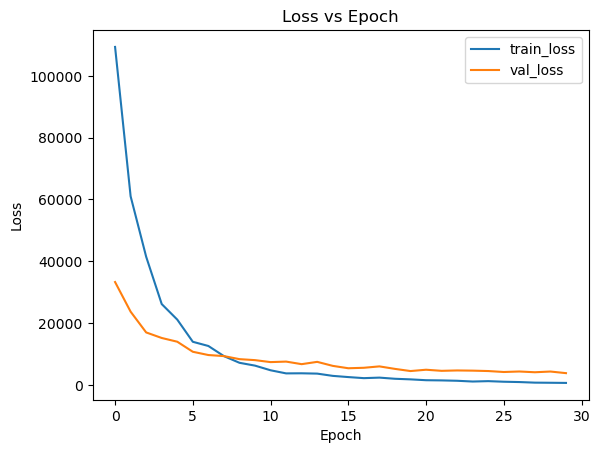

In [ ]:
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

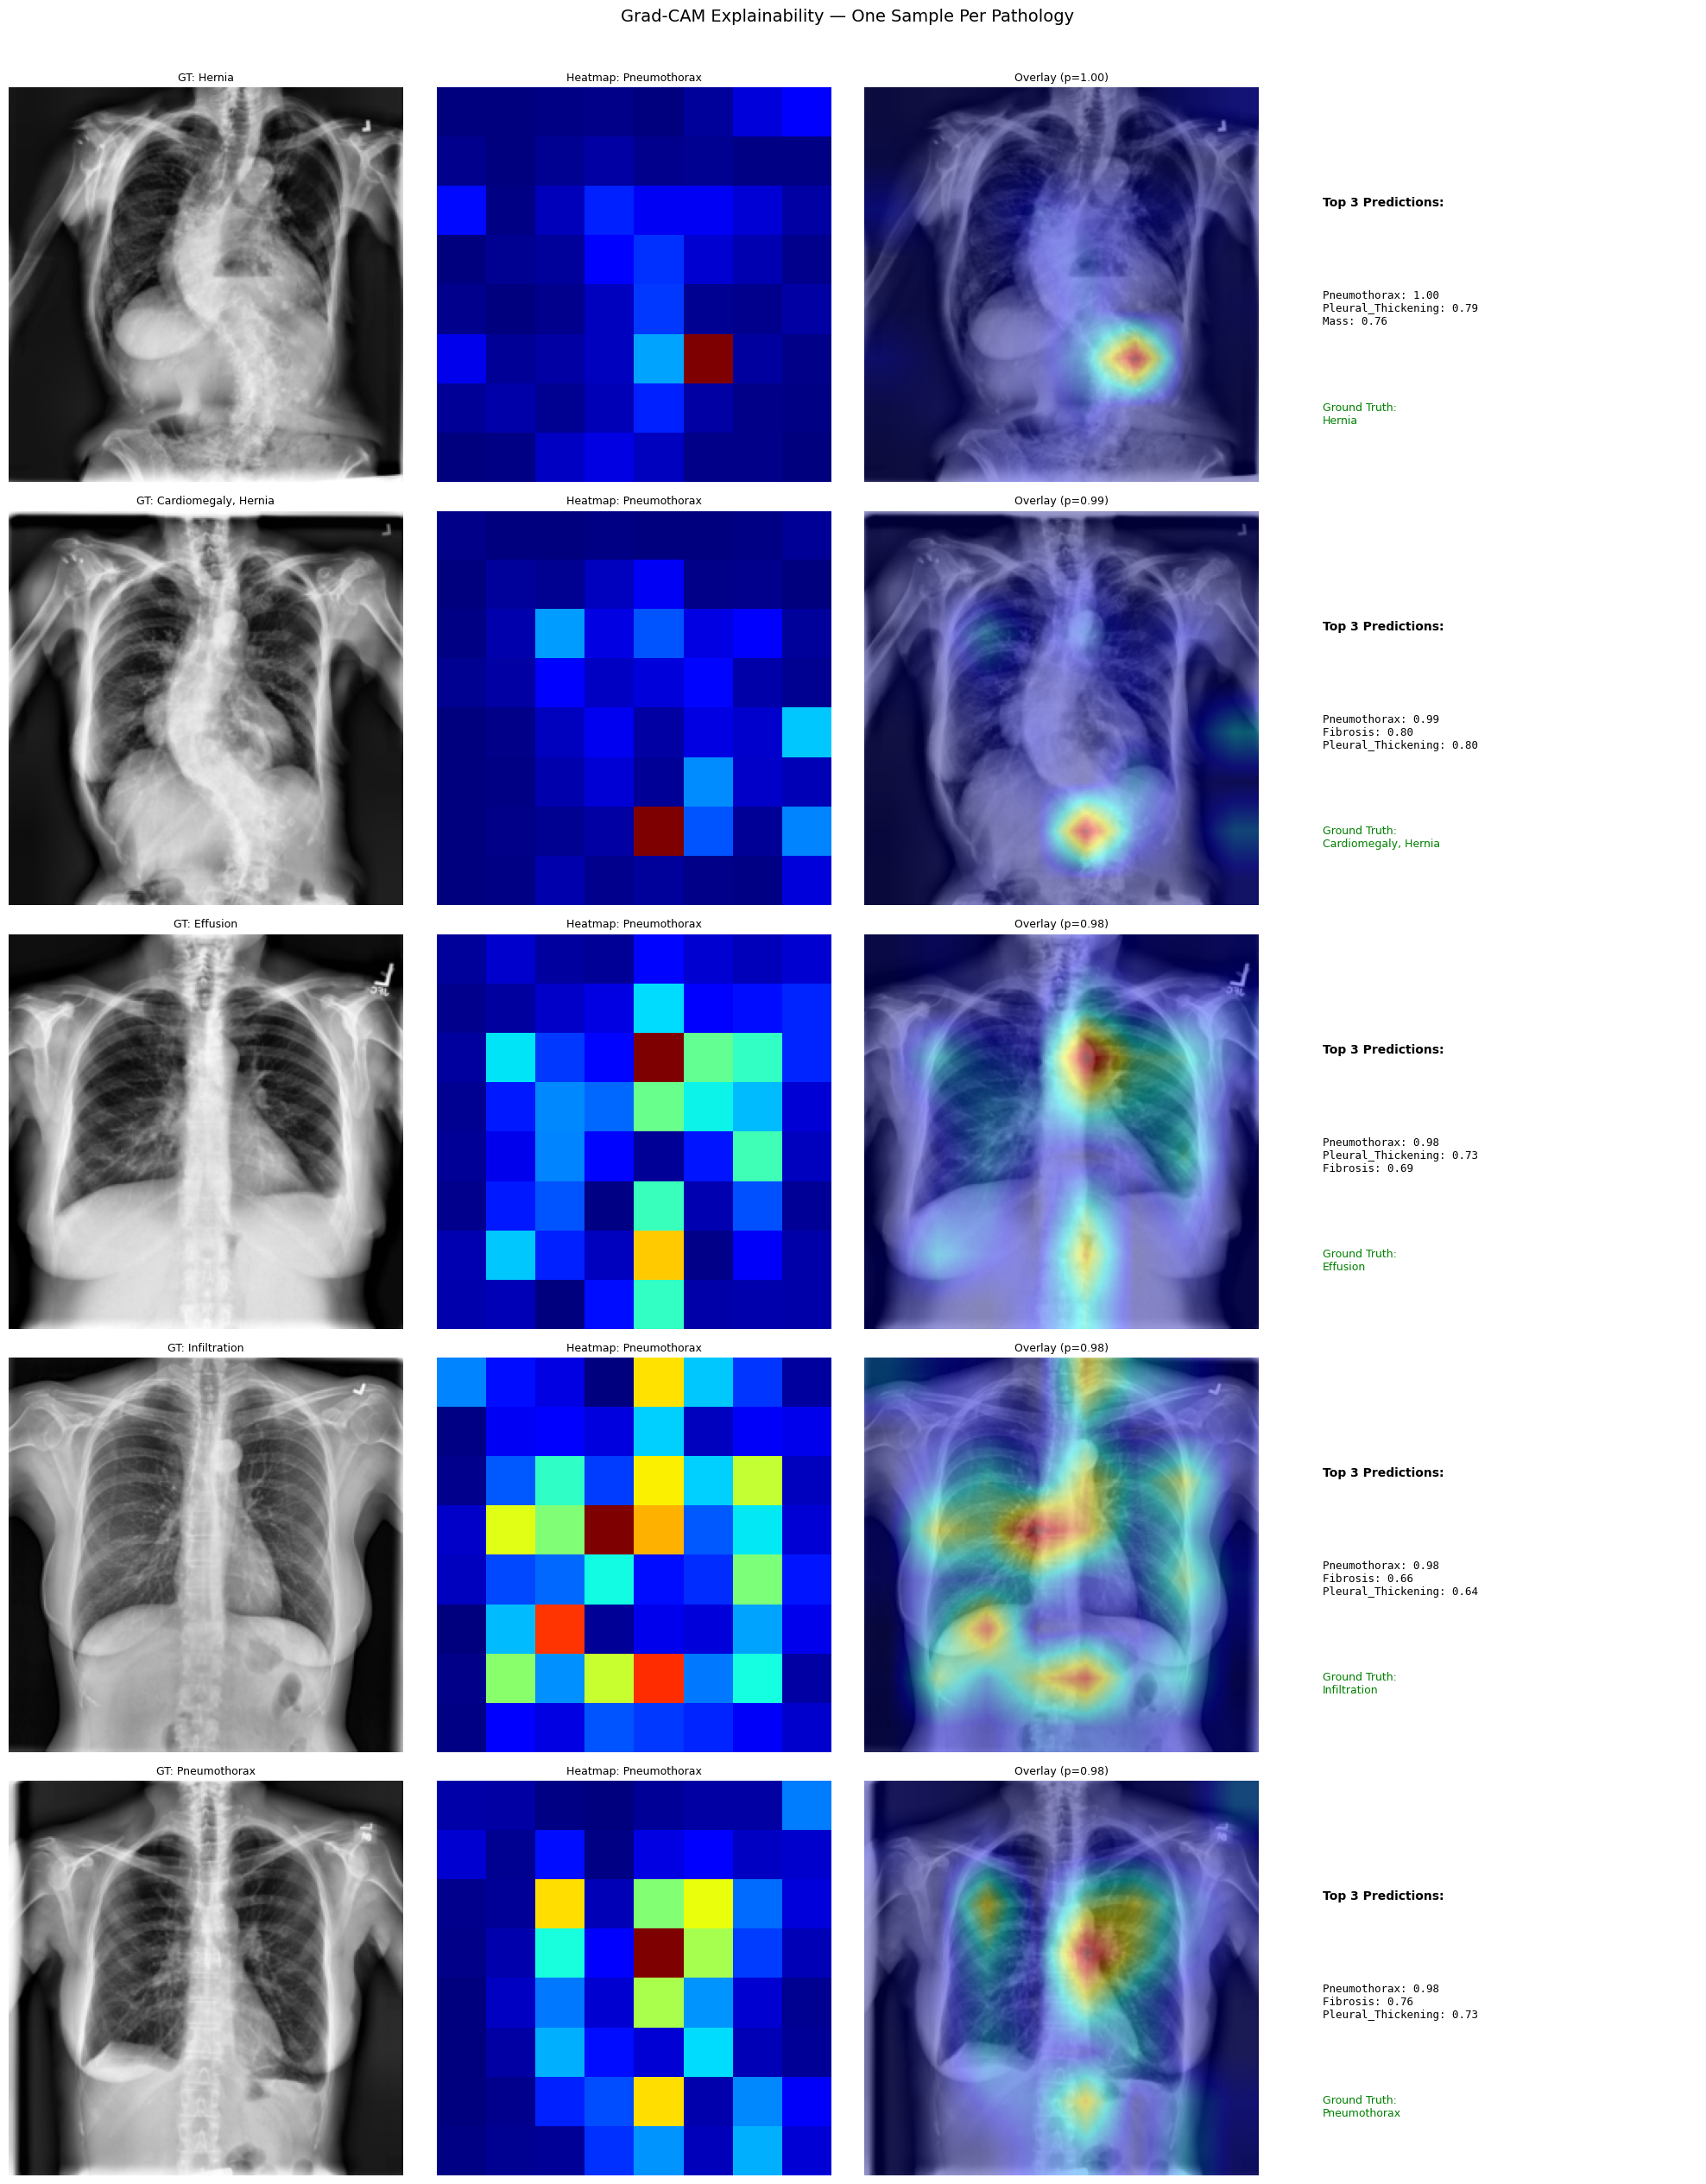

Pathologies shown: Hernia, Infiltration, Cardiomegaly, Pneumothorax, Effusion


In [ ]:
# Exploration with Grad-CAM, sampling one image per pathology for visualization, LLM for initial setup prior to domain application

target_layer = model.layer4[-1]
cam = GradCAM(model, target_layer)

# Load the best model before visualizing
checkpoint = torch.load("best_resnet50_nih.pt")
model.load_state_dict(checkpoint["state_dict"])
model.eval()

# Find one image per unique pathology
shown_classes = set()
samples = []

for idx in range(len(val_ds)):
    sample = val_ds[idx]
    if sample is None:
        continue
    active = [val_ds.classes[j] for j, v in enumerate(sample["labels"]) if v == 1]
    primary = active[0]
    if primary not in shown_classes and primary != "No Finding":
        shown_classes.add(primary)
        samples.append(sample)
    if len(samples) >= 5:
        break

# Fallback: if fewer than 5 pathologies found, fill with any remaining images
if len(samples) < 5:
    for idx in range(len(val_ds)):
        if len(samples) >= 5:
            break
        sample = val_ds[idx]
        if sample is None:
            continue
        active = [val_ds.classes[j] for j, v in enumerate(sample["labels"]) if v == 1]
        primary = active[0]
        if primary not in shown_classes:
            shown_classes.add(primary)
            samples.append(sample)

num_samples = len(samples)
fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
if num_samples == 1:
    axes = axes[np.newaxis, :]

for i, sample in enumerate(samples):
    input_tensor = sample["image"].unsqueeze(0).to(device)
    labels = sample["labels"]

    # Get predictions
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()

    # Top predicted class
    pred_idx = int(np.argmax(probs))
    pred_name = train_ds.classes[pred_idx]
    pred_prob = probs[pred_idx]

    # Ground truth labels
    gt_labels = [train_ds.classes[j] for j, val in enumerate(labels) if val == 1]

    # Generate heatmap for top prediction
    heatmap = cam.generate_heatmap(input_tensor, pred_idx)

    # Un-normalize the image for display
    img_np = input_tensor[0, 0].detach().cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    img_np = (img_np * 255).astype(np.uint8)

    overlay = overlay_heatmap(heatmap, img_np)

    # Top 3 predictions
    top3_idx = np.argsort(probs)[::-1][:3]
    top3_str = "\n".join([f"{train_ds.classes[j]}: {probs[j]:.2f}" for j in top3_idx])

    # Plot: Original | Heatmap | Overlay | Top 3 Predictions
    axes[i, 0].imshow(img_np, cmap="gray")
    axes[i, 0].set_title(f"GT: {', '.join(gt_labels)}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(heatmap, cmap="jet")
    axes[i, 1].set_title(f"Heatmap: {pred_name}", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[i, 2].set_title(f"Overlay (p={pred_prob:.2f})", fontsize=9)
    axes[i, 2].axis("off")

    axes[i, 3].axis("off")
    axes[i, 3].text(0.1, 0.7, "Top 3 Predictions:", fontsize=10, fontweight="bold",
                     transform=axes[i, 3].transAxes)
    axes[i, 3].text(0.1, 0.4, top3_str, fontsize=9, family="monospace",
                     transform=axes[i, 3].transAxes)
    axes[i, 3].text(0.1, 0.15, f"Ground Truth:\n{', '.join(gt_labels)}", fontsize=9,
                     color="green", transform=axes[i, 3].transAxes)

plt.suptitle("Grad-CAM Explainability — One Sample Per Pathology", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Pathologies shown: {', '.join(shown_classes)}")

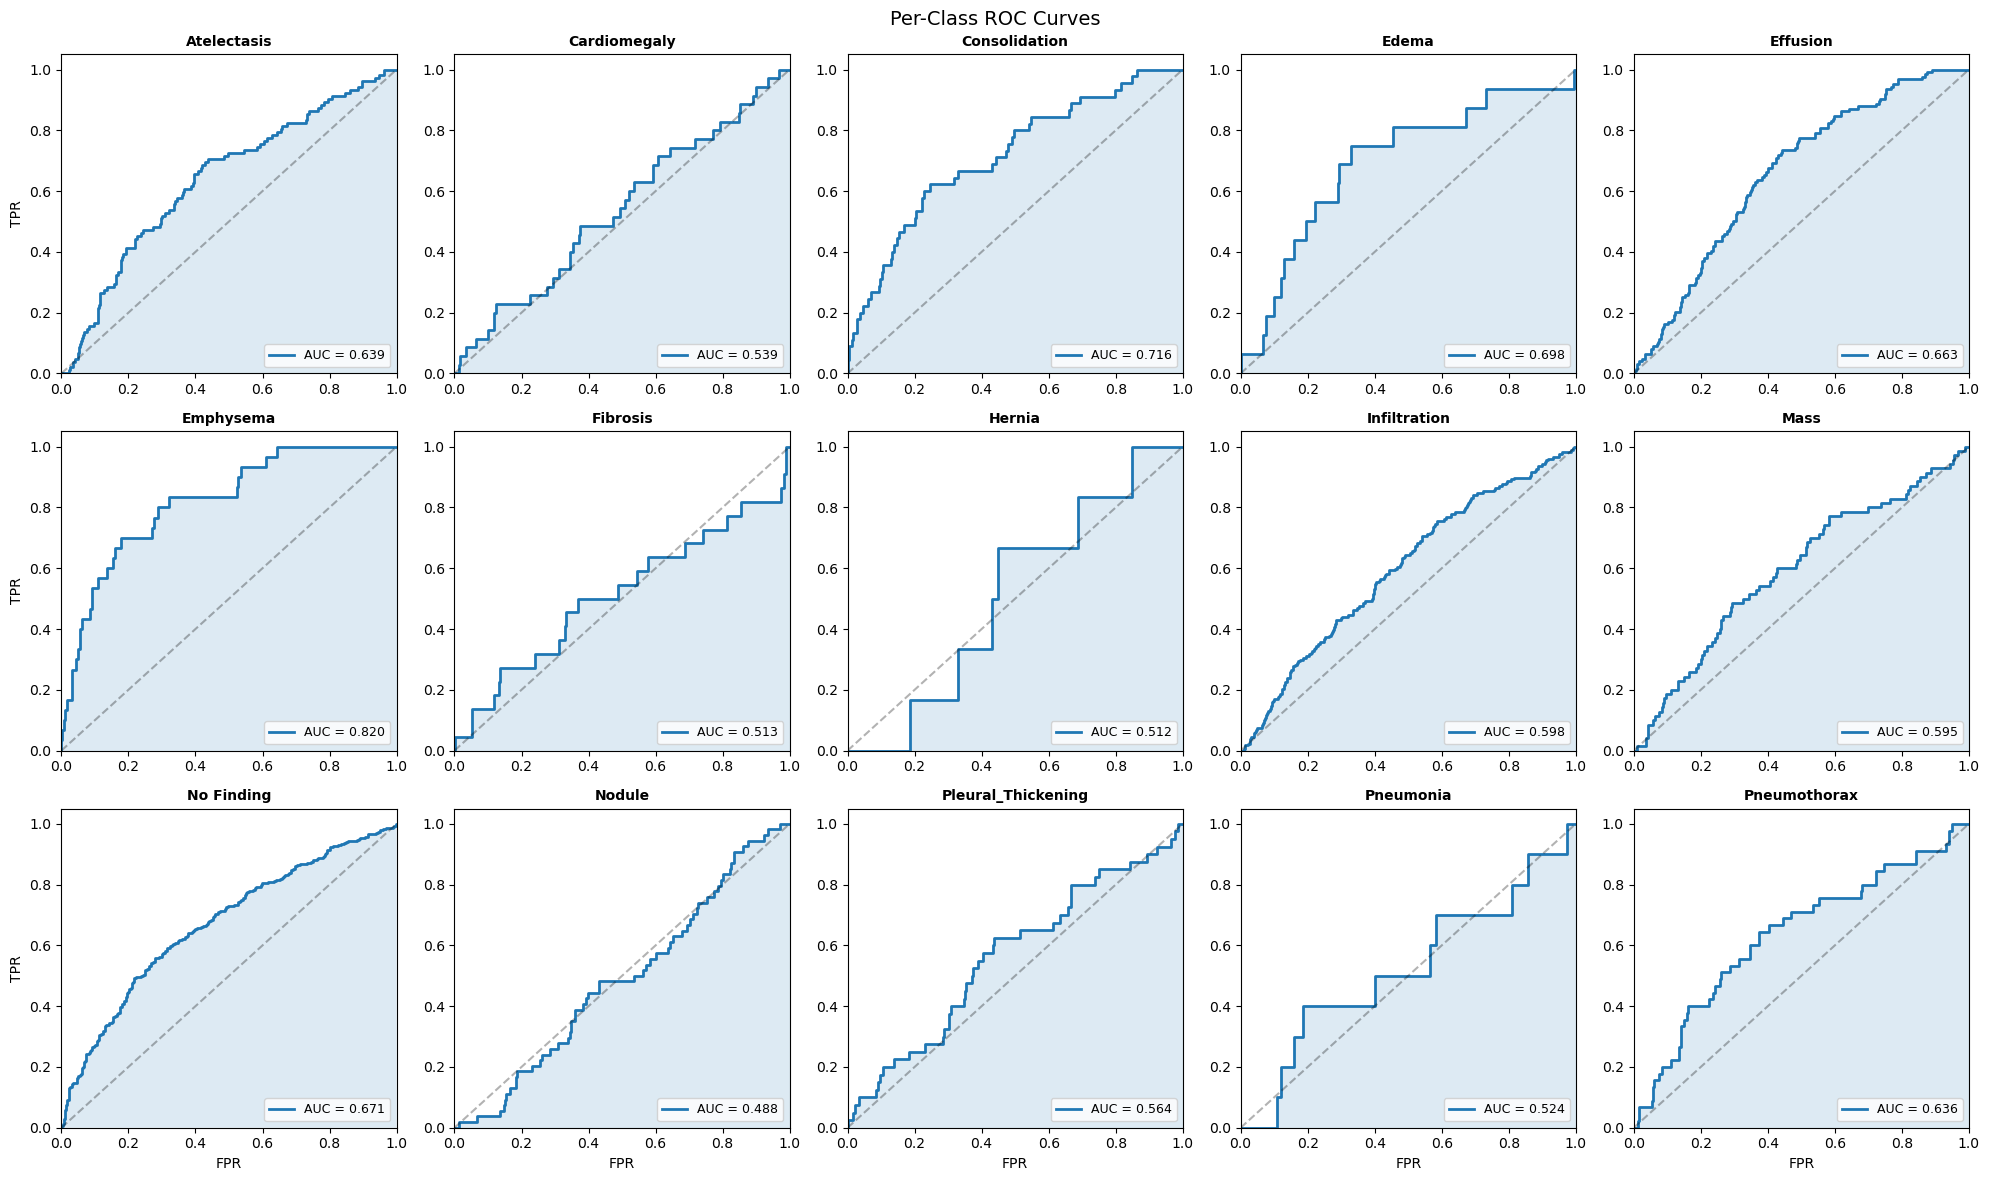

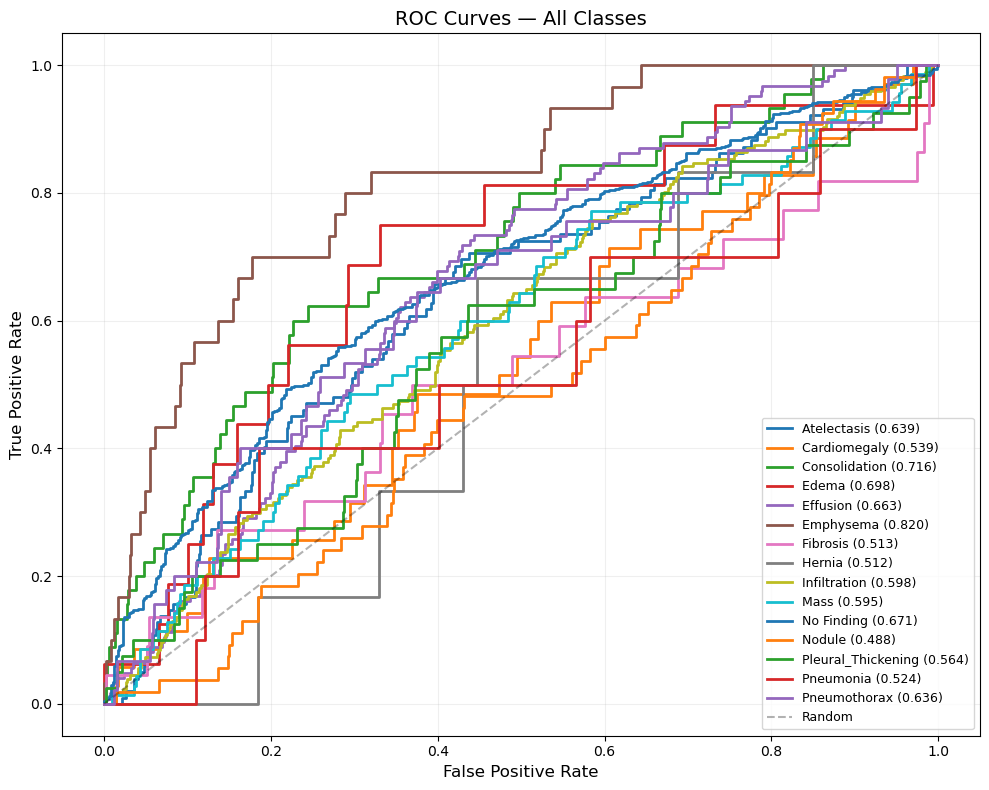

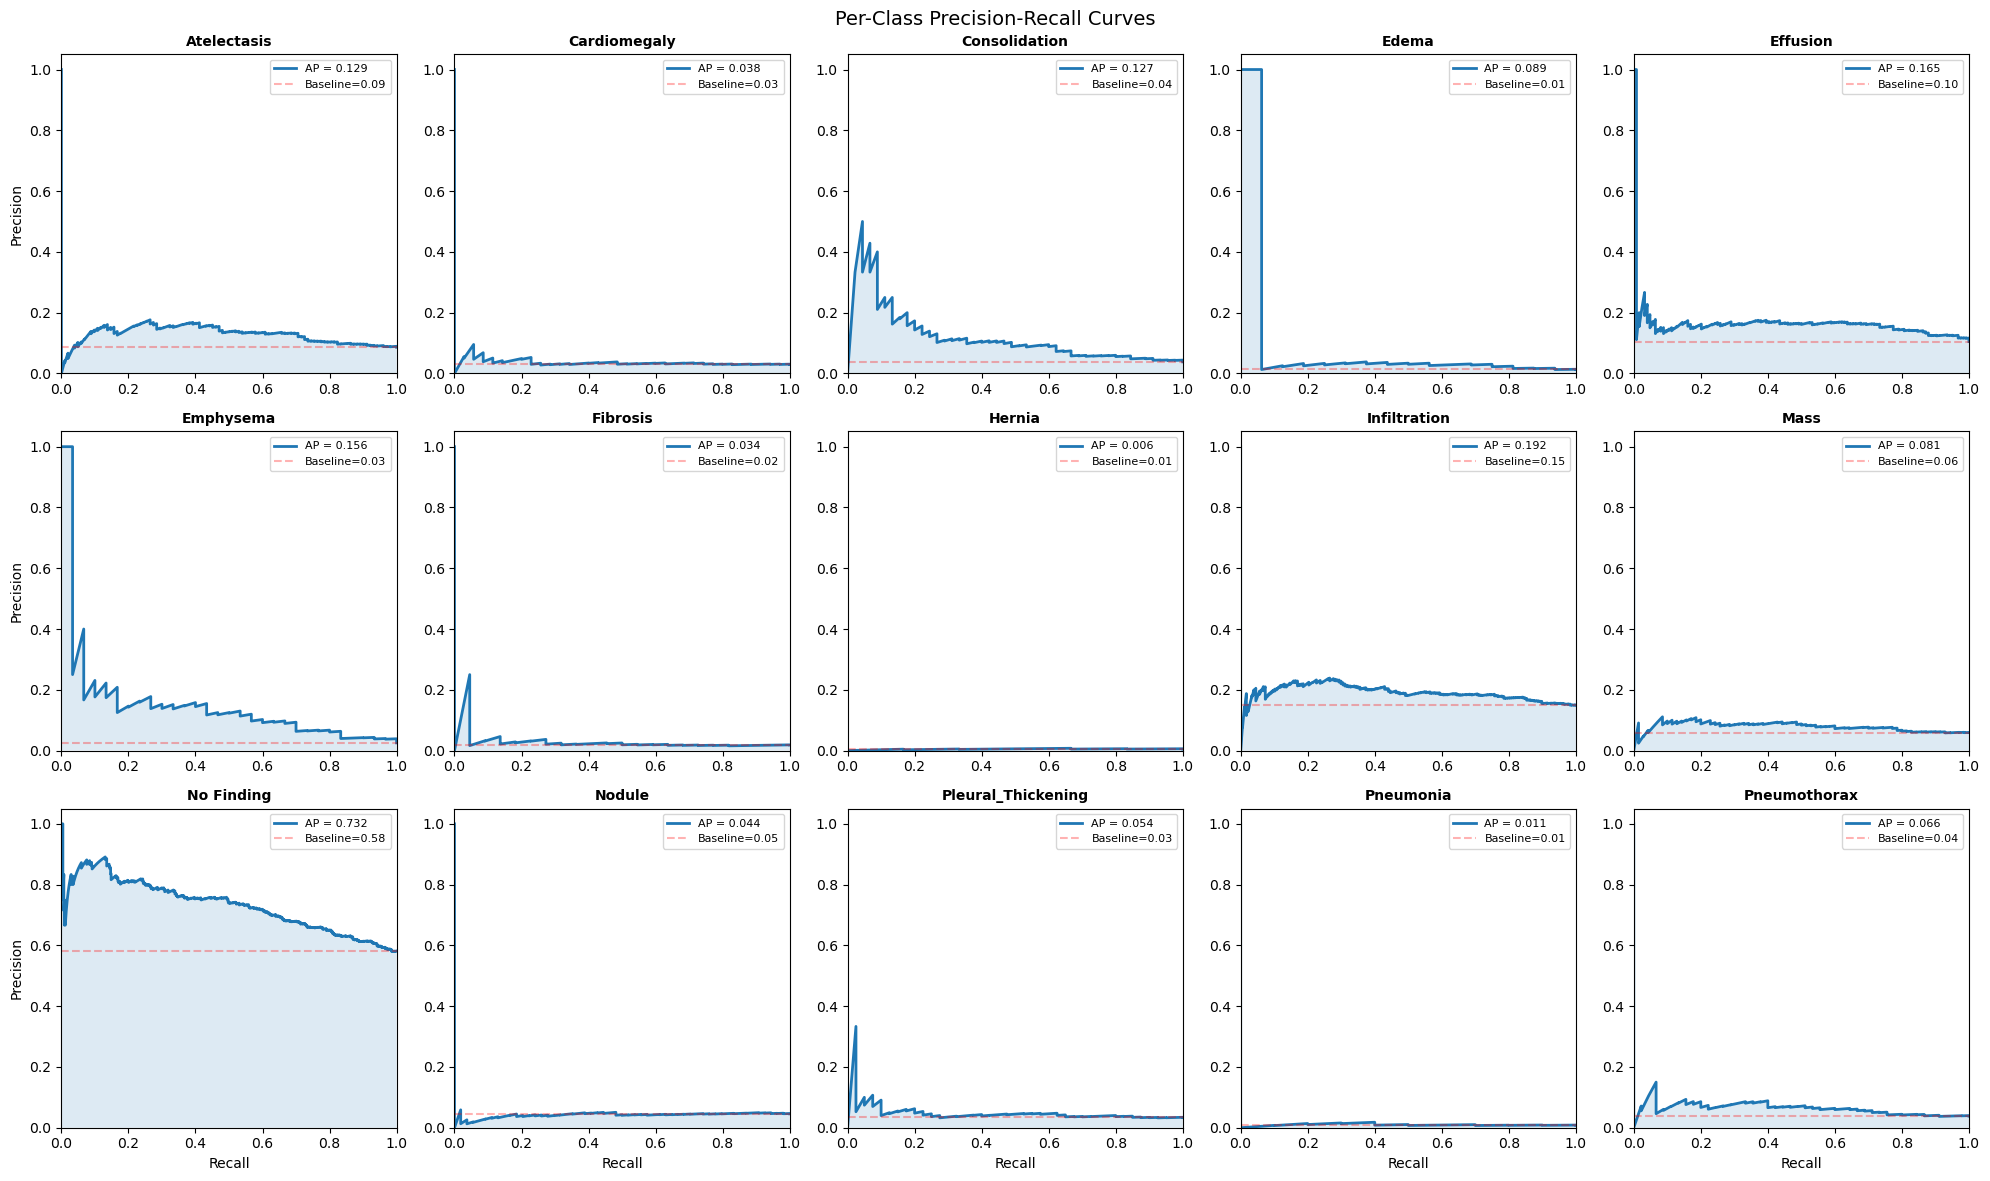

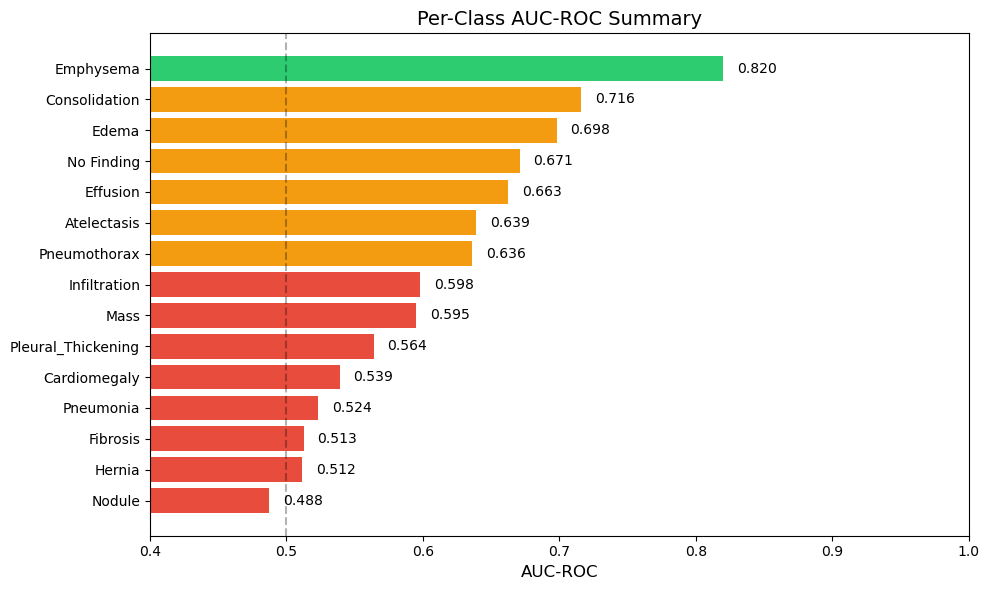

In [19]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Collect all predictions from validation set using best model
checkpoint = torch.load("best_resnet50_nih.pt")
model.load_state_dict(checkpoint["state_dict"])
model.eval()

all_labels, all_probs = [], []

with torch.no_grad():
    for batch in val_loader:
        if batch is None:
            continue
        x = batch["image"].to(device)
        y = batch["labels"]
        probs = torch.sigmoid(model(x))
        all_labels.append(y.numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
classes = train_ds.classes


# --- 1. Per-Class ROC Curves (the standard figure for this kind of project) ---
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, name in enumerate(classes):
    if i >= len(axes):
        break
    ax = axes[i]
    if len(np.unique(all_labels[:, i])) > 1:
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
        ax.fill_between(fpr, tpr, alpha=0.15)
    else:
        ax.text(0.3, 0.5, "No positive\nsamples", fontsize=10, transform=ax.transAxes)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlabel("FPR") if i >= 10 else None
    ax.set_ylabel("TPR") if i % 5 == 0 else None

# Hide unused subplots
for j in range(len(classes), len(axes)):
    axes[j].axis("off")

plt.suptitle("Per-Class ROC Curves", fontsize=14)
plt.tight_layout()
plt.show()


# --- 2. Combined ROC Overlay (good for comparing disease difficulty) ---
plt.figure(figsize=(10, 8))

for i, name in enumerate(classes):
    if len(np.unique(all_labels[:, i])) > 1:
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} ({roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Classes", fontsize=14)
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# --- 3. Precision-Recall Curves (more informative than ROC for imbalanced data) ---
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, name in enumerate(classes):
    if i >= len(axes):
        break
    ax = axes[i]
    if len(np.unique(all_labels[:, i])) > 1:
        precision, recall, _ = precision_recall_curve(all_labels[:, i], all_probs[:, i])
        ap = average_precision_score(all_labels[:, i], all_probs[:, i])
        ax.plot(recall, precision, linewidth=2, label=f"AP = {ap:.3f}")
        ax.fill_between(recall, precision, alpha=0.15)
        # Baseline = prevalence of the class
        prevalence = np.mean(all_labels[:, i])
        ax.axhline(y=prevalence, color="r", linestyle="--", alpha=0.3, label=f"Baseline={prevalence:.2f}")
    else:
        ax.text(0.3, 0.5, "No positive\nsamples", fontsize=10, transform=ax.transAxes)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xlabel("Recall") if i >= 10 else None
    ax.set_ylabel("Precision") if i % 5 == 0 else None

for j in range(len(classes), len(axes)):
    axes[j].axis("off")

plt.suptitle("Per-Class Precision-Recall Curves", fontsize=14)
plt.tight_layout()
plt.show()


# --- 4. AUC Bar Chart Summary (quick snapshot for a presentation slide) ---
auc_scores = {}
for i, name in enumerate(classes):
    if len(np.unique(all_labels[:, i])) > 1:
        auc_scores[name] = roc_auc_score(all_labels[:, i], all_probs[:, i])

sorted_scores = dict(sorted(auc_scores.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 6))
colors = ["#2ecc71" if v >= 0.75 else "#f39c12" if v >= 0.6 else "#e74c3c" for v in sorted_scores.values()]
bars = plt.barh(list(sorted_scores.keys()), list(sorted_scores.values()), color=colors)
plt.xlabel("AUC-ROC", fontsize=12)
plt.title("Per-Class AUC-ROC Summary", fontsize=14)
plt.xlim([0.4, 1.0])
plt.axvline(x=0.5, color="k", linestyle="--", alpha=0.3, label="Random")

for bar, score in zip(bars, sorted_scores.values()):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f"{score:.3f}", va="center", fontsize=10)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()